In [1]:
# Copyright [2025] [KTH Royal Institute of Technology] 
# Licensed under the Educational Community License, Version 2.0 (ECL-2.0)
# This file is part of the materials for EL2805 - Reinforcement Learning - Exercise Session 3 at KTH, Stockholm.

import numpy as np
import gymnasium as gym
from collections import deque, namedtuple
import torch
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

from DQN_agent import Agent
from Agent import MyNetwork

In [2]:
# tensorboard --logdir=runs/lunar_lander_dqn/
    
writer = SummaryWriter(log_dir="runs/lunar_lander_dqn")


# Define Experience tuple
# Experience represents a transition in the environment, including the current state, action taken,
# received reward, next state, and whether the episode is done.
Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

class ExperienceReplayBuffer:
    """Replay buffer for storing experiences.
    
       The experience replay buffer stores past experiences so that the agent can learn from them later.
       By sampling randomly from these experiences, the agent avoids overfitting to the most recent 
       transitions and helps stabilize training.
       - The buffer size is limited, and older experiences are discarded to make room for new ones.
       - Experiences are stored as tuples of (state, action, reward, next_state, done).
       - A batch of experiences is sampled randomly during each training step for updating the Q-values."""

    def __init__(self, maximum_length):
        self.buffer = deque(maxlen=maximum_length)  # Using deque ensures efficient removal of oldest elements

    def append(self, experience):
        """Add a new experience to the buffer"""
        self.buffer.append(experience)

    def __len__(self):
        """Return the current size of the buffer"""
        return len(self.buffer)

    def sample_batch(self, n):
        """Randomly sample a batch of experiences"""
        if n > len(self.buffer):
            raise IndexError('Sample size exceeds buffer size!')
        indices = np.random.choice(len(self.buffer), size=n, replace=False)  # Random sampling
        batch = [self.buffer[i] for i in indices]  # Create a batch from sampled indices
        return zip(*batch)  # Unzip batch into state, action, reward, next_state, and done

In [3]:
### Parameters ###
N_EPISODES = 20  # Number of training episodes (T_E) # 250
GAMMA = 0.99  # Discount factor (how much future rewards are considered) # 0.99
BUFFER_SIZE = 10000  # Size of the replay buffer (L) # 10000
EPSILON_MIN = 0.01 # Minimum exploration rate # 0.01
EPSILON_MAX = 0.99 # Maximum exploration rate # 0.99
EPSILON_DECAY_PERIOD = 0.95 # share of episodes during which epsilon decays linearly # 0.95
BATCH_SIZE = 32  # Number of experiences to sample from the replay buffer per update # 32
LEARNING_RATE = 0.001  # Learning rate for the optimizer (alpha) # 0.001
MAX_STEPS = 1000  # Maximum number of steps per episode # 1000
TARGET_UPDATE_PERIOD = BUFFER_SIZE//BATCH_SIZE # BUFFER_SIZE//BATCH_SIZE
assert TARGET_UPDATE_PERIOD > 0
CLIPPING_VALUE = 1.0 # 1.0

In [4]:
# Import and initialize the discrete Lunar Lander Environment
env = gym.make('LunarLander-v3')
# If you want to render the environment while training run instead:
# env = gym.make('LunarLander-v3', render_mode = "human")
env.reset()


# Initialize experience replay buffer
buffer = ExperienceReplayBuffer(maximum_length=BUFFER_SIZE)

# Initialize the Q-network (state -> Q-values for actions)
layer_sizes = [
    env.observation_space.shape[0],
    64,
    env.action_space.n
]
main_network = MyNetwork(layer_sizes)
target_network = MyNetwork(layer_sizes)
target_network.load_state_dict(main_network.state_dict())
target_network.eval()

# Optimizer for training the Q-network
optimizer = optim.Adam(main_network.parameters(), lr=LEARNING_RATE)  # Adam optimizer for efficient training


def select_action(state, epsilon):
    """Epsilon-greedy action selection
    # We balance exploration and exploitation using epsilon-greedy.
    # Exploration: Choose a random action.
    # Exploitation: Choose the action with the highest Q-value (the optimal action)."""
    if random.random() < epsilon:
        return env.action_space.sample()  # Explore by selecting a random action
    else:
        state_tensor = torch.tensor([state], dtype=torch.float32)  # Convert state to tensor
        return target_network(state_tensor).argmax().item()  # Exploit by selecting the action with max Q-value


/home/viktor/miniconda3/envs/EL2805/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [5]:
# Training loop
step_counter = 0
total_episode_rewards = []
episode_number_of_steps = []
for episode in range(N_EPISODES):
    state = env.reset()[0]  # Reset environment and get initial state
    total_reward = 0

    epsilon = max(EPSILON_MIN, EPSILON_MAX - (EPSILON_MAX - EPSILON_MIN)*(episode)/(EPSILON_DECAY_PERIOD*N_EPISODES-1))

    for t in range(MAX_STEPS):
        # Choose action using epsilon-greedy policy
        action = select_action(state, epsilon)

        # Execute action in environment and get feedback (next state, reward, etc.)
        next_state, reward, terminal, truncated, _ = env.step(action)
        done = terminal or truncated  # Done is True if episode ends
        total_reward += reward

        # Store the experience (state, action, reward, next state, done) in the buffer
        buffer.append(Experience(state, action, reward, next_state, done))
        state = next_state  # Update state for the next step

        # Training step: update Q-values using a batch of experiences from the buffer
        if len(buffer) >= BATCH_SIZE:
            # Sample a batch of experiences from the buffer
            states, actions, rewards, next_states, dones = buffer.sample_batch(BATCH_SIZE)

            # Convert the batch data into tensors
            states = torch.tensor(states, dtype=torch.float32)
            actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)  # Unsqueeze for correct shape
            rewards = torch.tensor(rewards, dtype=torch.float32)
            next_states = torch.tensor(next_states, dtype=torch.float32)
            dones = torch.tensor(dones, dtype=torch.float32)

            # Compute Q-values for the current states using MAIN network
            q_values = main_network(states).gather(1, actions).squeeze()  # Q-values for taken actions

            # Compute the target Q-values for the next using TARGET network
            with torch.no_grad():  # No need to compute gradients for target Q-values
                next_q_values = target_network(next_states).max(1)[0]  # Max Q-value for next state
                targets = rewards + GAMMA * next_q_values * (1 - dones)  # Target: Bellman equation

            # Compute the loss (MSE loss between predicted Q-values and target Q-values)
            loss = nn.functional.mse_loss(q_values, targets)
               
            # Backpropagation step: update network parameters
            optimizer.zero_grad()  # Zero gradients before backpropagation
            loss.backward()  # Compute gradients
            nn.utils.clip_grad_norm_(main_network.parameters(), max_norm=CLIPPING_VALUE)  # Clip gradients to avoid exploding gradients
            optimizer.step()  # Update parameters

            # Log loss to TensorBoard for visualization
            writer.add_scalar("Loss", loss.item(), episode * MAX_STEPS + t)
        
        if step_counter % TARGET_UPDATE_PERIOD == 0:
            target_network.load_state_dict(main_network.state_dict())
        step_counter = (step_counter + 1) % TARGET_UPDATE_PERIOD

        if done:  # If the episode ends
            break

    # Log total reward and epsilon to TensorBoard
    writer.add_scalar("Total Reward", total_reward, episode)
    writer.add_scalar("Epsilon", epsilon, episode)
    
    total_episode_rewards.append(total_reward)
    episode_number_of_steps.append(t+1)

    # Print progress for each episode
    print(f"Episode {episode + 1}/{N_EPISODES}: Total Reward: {total_reward}")

    # TODO remove False below
    if False and episode % 50 == 0 \
        and len(total_episode_rewards) >= 50 \
        and np.mean(total_episode_rewards[-50:]) - np.std(total_episode_rewards) * 2.3 / np.sqrt(50) >= 50:  # If the agent achieves good performance, stop early # TODO change to running average
        break

# Close the environment after training
env.close()
writer.close()

/tmp/ipykernel_37349/2397533754.py:30: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1764720583314/work/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor(states, dtype=torch.float32)


Episode 1/20: Total Reward: -166.51757032687783
Episode 2/20: Total Reward: -217.4156994621996
Episode 3/20: Total Reward: -106.41766855008423
Episode 4/20: Total Reward: -89.17982393876001
Episode 5/20: Total Reward: -264.51075125670457
Episode 6/20: Total Reward: -112.27245985498391
Episode 7/20: Total Reward: -162.50822907530227
Episode 8/20: Total Reward: -264.4523462262896
Episode 9/20: Total Reward: -248.53279463216543
Episode 10/20: Total Reward: -252.3320175797385
Episode 11/20: Total Reward: -178.18576720724948
Episode 12/20: Total Reward: -221.51456192568938
Episode 13/20: Total Reward: -69.04312301628798
Episode 14/20: Total Reward: -86.99918011773036
Episode 15/20: Total Reward: -109.27698653299385
Episode 16/20: Total Reward: -513.642420239191
Episode 17/20: Total Reward: -24.617705350218372
Episode 18/20: Total Reward: 211.8901333117072
Episode 19/20: Total Reward: 134.97434988476442
Episode 20/20: Total Reward: -101.85620196949151


In [ ]:
# torch.save(main_network, 'neural-network-1.pth')
name = f"DQN_gamma_{GAMMA:.2f}_buffer_{BUFFER_SIZE}_N_{N_EPISODES}"
torch.save(main_network, 'nets/name.pth')

In [7]:
def running_average(l, n):
    assert len(l)
    return np.array([
        np.mean(l[max(0,i-n):i])
        for i in range(1, len(l))
    ])

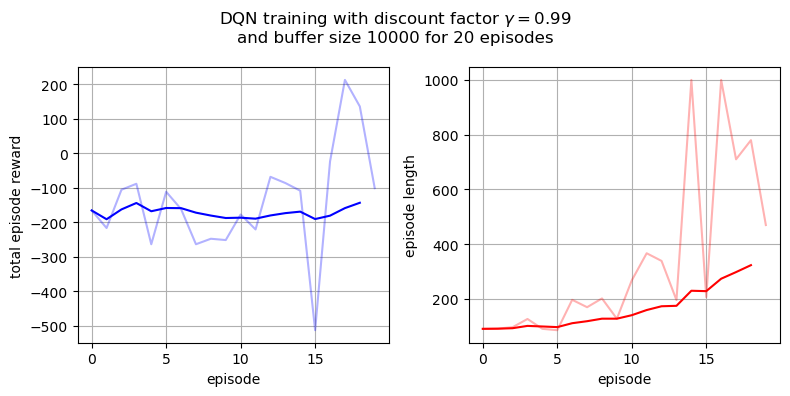

In [13]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))

fig.suptitle(f"DQN training with discount factor $\\gamma={GAMMA:.2f}$\nand buffer size {BUFFER_SIZE} for {N_EPISODES} episodes")

ax1.plot(running_average(total_episode_rewards, 25), color="b")
ax1.plot(total_episode_rewards, alpha=0.3, color="b")
ax1.grid()
ax1.set_xlabel("episode")
ax1.set_ylabel("total episode reward")

ax2.plot(running_average(episode_number_of_steps, 25), color="red")
ax2.plot(episode_number_of_steps, alpha=0.30, color="red")
ax2.grid()
ax2.set_xlabel("episode")
ax2.set_ylabel("episode length")

fig.tight_layout()
fig.savefig(f"plots/{name}.png")

plt.show()